RQA/CRQA Statistics and Visualization Notebook
================================================
Analyzes recurrence quantification analysis results for pose data.
Generates statistical tables and figures for manuscript.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import sys
sys.path.append('utils')
from stats_utils import (
    run_rpy2_lmer,
    fmt,
    COND_ORDER,
    NON_METRIC_COLS,
    pretty_metric,
    run_stats_by_column
)
from nb_utils import build_rqa_table
from viz_utils import create_2x2_figure

# 1. Configuration
Configure analysis parameters: Set the session type and normalization method to analyze. The normalization affects which head movement features are available (see CRQA mappings below).

In [14]:
# Data files - adjust these paths as needed
SESSION = "experimental"  # or "baseline"
NORMALIZATION = "original"  # or "procrustes_global"

RQA_FILE = f"data/rqa/{SESSION}_{NORMALIZATION}_rqa_crqa.csv"
OUTPUT_DIR = Path("tables/rqa_stats_results")
FIGS_DIR = Path("figs") / f"{SESSION}_{NORMALIZATION}_rqa"

# Create output directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Metrics to extract from RQA results
# These capture different aspects of temporal dynamics:
# - Recurrence/Determinism: repetitiveness and predictability
# - Line lengths: stability of recurring states
# - Entropy/Laminarity: complexity and intermittency
# - Divergence: rate of trajectory separation
RQA_METRICS = [
    "perc_recur",        # % of recurrent points
    "perc_determ",       # % of recurrent points forming diagonal lines
    "maxl_found",        # longest diagonal line
    "mean_line_length",  # average diagonal line length
    "std_line_length",   # variability in line lengths
    "entropy",           # complexity of line length distribution
    "laminarity",        # % of recurrent points in vertical lines
    "trapping_time",     # average vertical line length
    "vmax",              # longest vertical line
    "divergence",        # inverse of maxl (trajectory separation rate)
    "trend_lower_diag",  # nonstationarity below main diagonal
    "trend_upper_diag"   # nonstationarity above main diagonal
]
print(f"Loading RQA data from: {RQA_FILE}")
df = pd.read_csv(RQA_FILE)

# Standardize condition labels to ensure proper ordering (Low → Moderate → High)
df["participant"] = df["participant"].astype(str)
df["condition"] = df["condition"].astype(str).str.strip().str.upper()
df["condition"] = pd.Categorical(df["condition"], categories=COND_ORDER, ordered=True)

# Filter to valid conditions only
df = df[df["condition"].isin(COND_ORDER)].copy()

# Coerce metric columns to numeric (handles any string values)
for col in RQA_METRICS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Loaded {len(df)} rows across {df['column'].nunique()} data types")
print(f"Participants: {sorted(df['participant'].unique())}")
print(f"Data types: {sorted(df['column'].unique())}")

Loading RQA data from: data/rqa/experimental_original_rqa_crqa.csv
Loaded 41846 rows across 13 data types
Participants: ['402', '404', '407', '408', '409', '410', '411', '412', '413', '414', '415', '416', '417', '418', '419', '420', '421', '422', '423', '424', '425', '426', '427', '428', '429', '430', '431', '432', '433', '434', '435', '437', '438', '439', '440', '441', '442', '443', '444', '445', '446', '447', '448', '449', '450', '451', '452', '453', '454', '455', '456', '457', '458', '459', '460', '461', '462', '463', '464', '465', '466', '467', '468', '469', '470', '471', '472', '473', '474', '475', '476', '477']
Data types: ['blink_aperture', 'center_face_magnitude', 'center_face_x', 'center_face_y', 'crqa_head_pupil_mag', 'crqa_head_pupil_x', 'crqa_head_pupil_y', 'head_rotation_rad', 'interocular', 'mouth_aperture', 'pupil_dx', 'pupil_dy', 'pupil_metric']


# 2. Statistical Analysis
Run mixed-effects models: Fit linear mixed-effects models for each RQA metric across all data types. Models include random intercepts for participants and test load effects with post-hoc pairwise comparisons.

In [15]:
print("\n" + "="*70)
print("RUNNING STATISTICAL MODELS")
print("="*70)

# Runs LME models via rpy2 for each column × metric combination
# Returns: dict[column][metric] → (estimates, p-values, means, sems)
stats_results = run_stats_by_column(df, RQA_METRICS)


RUNNING STATISTICAL MODELS

Analyzing: blink_aperture
  ✓ perc_recur
  ✓ perc_determ
  ✓ maxl_found
  ✓ mean_line_length
  ✓ std_line_length
  ✓ entropy
  ✓ laminarity
  ✓ trapping_time
  ✓ vmax
  ✓ divergence
  ✓ trend_lower_diag
  ✓ trend_upper_diag

Analyzing: center_face_magnitude
  ✓ perc_recur
  ✓ perc_determ
  ✓ maxl_found
  ✓ mean_line_length
  ✓ std_line_length
  ✓ entropy
  ✓ laminarity
  ✓ trapping_time
  ✓ vmax
  ✓ divergence
  ✓ trend_lower_diag
  ✓ trend_upper_diag

Analyzing: center_face_x
  ✓ perc_recur
  ✓ perc_determ
  ✓ maxl_found
  ✓ mean_line_length
  ✓ std_line_length
  ✓ entropy
  ✓ laminarity
  ✓ trapping_time
  ✓ vmax
  ✓ divergence
  ✓ trend_lower_diag
  ✓ trend_upper_diag

Analyzing: center_face_y
  ✓ perc_recur
  ✓ perc_determ
  ✓ maxl_found
  ✓ mean_line_length
  ✓ std_line_length
  ✓ entropy
  ✓ laminarity
  ✓ trapping_time
  ✓ vmax
  ✓ divergence
  ✓ trend_lower_diag
  ✓ trend_upper_diag

Analyzing: crqa_head_pupil_mag
  ✓ perc_recur
  ✓ perc_determ
  ✓ 

R callback write-console: boundary (singular) fit: see help('isSingular')
  
R callback write-console: boundary (singular) fit: see help('isSingular')
  


  ✓ vmax
  ✓ divergence
  ✓ trend_lower_diag
  ✓ trend_upper_diag

Analyzing: crqa_head_pupil_y
  ✓ perc_recur
  ✓ perc_determ
  ✓ maxl_found
  ✓ mean_line_length
  ✓ std_line_length
  ✓ entropy
  ✓ laminarity


R callback write-console: boundary (singular) fit: see help('isSingular')
  


  ✓ trapping_time
  ✓ vmax
  ✓ divergence
  ✓ trend_lower_diag
  ✓ trend_upper_diag

Analyzing: head_rotation_rad
  ✓ perc_recur
  ✓ perc_determ
  ✓ maxl_found
  ✓ mean_line_length
  ✓ std_line_length
  ✓ entropy
  ✓ laminarity
  ✓ trapping_time
  ✓ vmax
  ✓ divergence
  ✓ trend_lower_diag
  ✓ trend_upper_diag

Analyzing: interocular
  ✓ perc_recur
  ✓ perc_determ
  ✓ maxl_found
  ✓ mean_line_length
  ✓ std_line_length
  ✓ entropy
  ✓ laminarity
  ✓ trapping_time
  ✓ vmax
  ✓ divergence
  ✓ trend_lower_diag
  ✓ trend_upper_diag

Analyzing: mouth_aperture
  ✓ perc_recur
  ✓ perc_determ
  ✓ maxl_found
  ✓ mean_line_length
  ✓ std_line_length
  ✓ entropy
  ✓ laminarity
  ✓ trapping_time
  ✓ vmax
  ✓ divergence
  ✓ trend_lower_diag
  ✓ trend_upper_diag

Analyzing: pupil_dx
  ✓ perc_recur
  ✓ perc_determ
  ✓ maxl_found
  ✓ mean_line_length
  ✓ std_line_length
  ✓ entropy
  ✓ laminarity
  ✓ trapping_time
  ✓ vmax
  ✓ divergence
  ✓ trend_lower_diag
  ✓ trend_upper_diag

Analyzing: pupil_dy
 

# 3. Build Latex Table
Creates a formatted LaTeX table with β coefficients and p-values for all metrics and data types.

In [16]:
table_file = OUTPUT_DIR / f"{SESSION}_{NORMALIZATION}_rqa_table.tex"
build_rqa_table(stats_results, table_file)


✅ Table written to: tables/rqa_stats_results/experimental_original_rqa_table.tex


# 4. Bar Plots
Generate 2×2 barplot figure: figure showing key RQA/CRQA results with error bars (±1 SEM) and significance markers.


CREATING FIGURE


/Users/cartersale/Documents/Research/Manuscripts/MATB_Nature/Pose/utils/viz_utils.py:512: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = dsub.groupby("condition")[metric].agg(["mean", sem]).reindex(COND_ORDER)
/Users/cartersale/Documents/Research/Manuscripts/MATB_Nature/Pose/utils/viz_utils.py:512: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = dsub.groupby("condition")[metric].agg(["mean", sem]).reindex(COND_ORDER)
/Users/cartersale/Documents/Research/Manuscripts/MATB_Nature/Pose/utils/viz_utils.py:512: FutureWarning: The default of observed=False is deprecated and will be changed to True in a futu

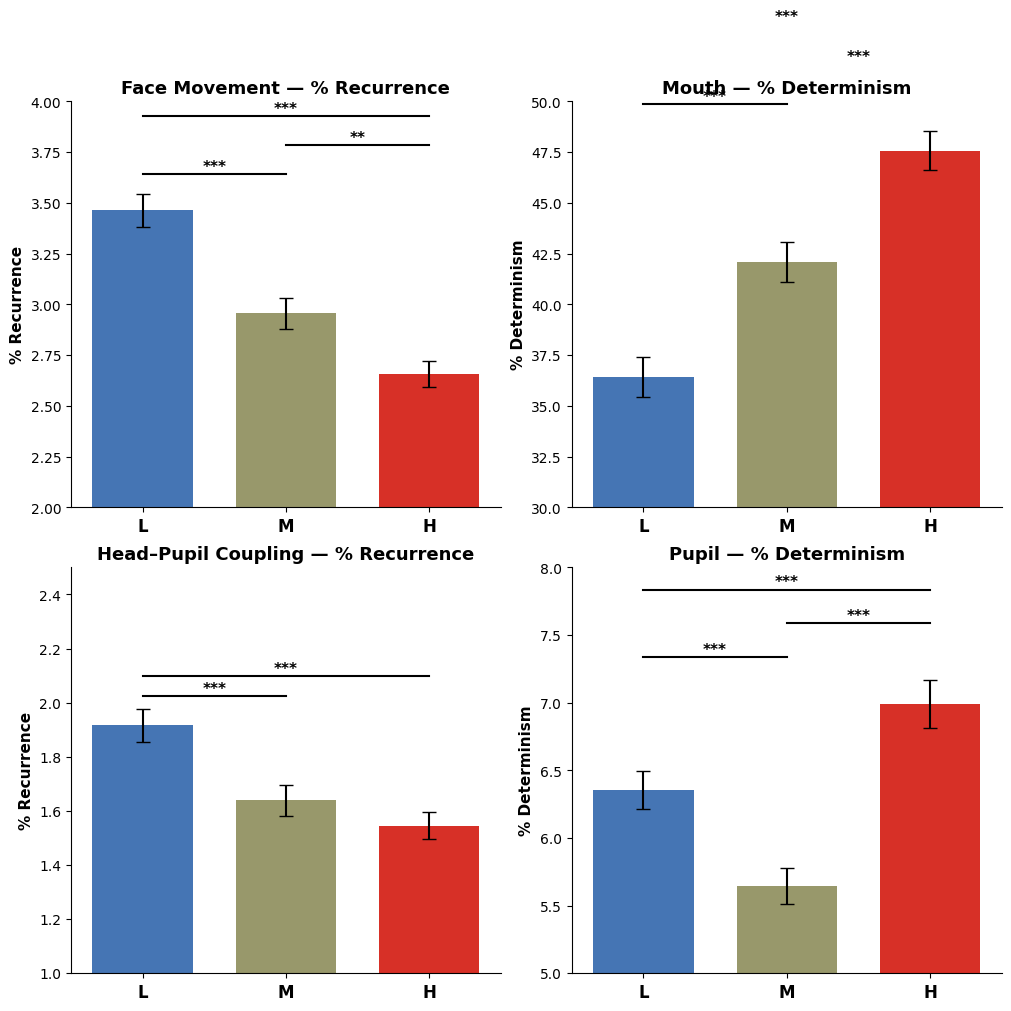

✅ Figure saved to: figs/experimental_original_rqa/experimental_original_rqa_2x2.svg


In [30]:
# ══════════════════════════════════════════════════════════════════════
# 4. VISUALIZATION: 2x2 BARPLOT FIGURE
# ══════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("CREATING FIGURE")
print("="*70)

custom_specs = [
    # Panel 1: Face movement fragmentation
    ("center_face_magnitude", "perc_recur", 
     "Face Movement — % Recurrence", "% Recurrence", (2, 4)),
    
    # Panel 2: Mouth progressive structuring (divergent pattern)
    ("mouth_aperture", "perc_determ",
     "Mouth — % Determinism", "% Determinism", (30, 50)),
    
    # Panel 3: Gaze-head decoupling
    ("crqa_head_pupil_mag", "perc_recur",
     "Head–Pupil Coupling — % Recurrence", "% Recurrence", (1, 2.5)),
    
    # Panel 4: Reorganization signature (U-shaped pattern)
    ("pupil_metric", "perc_determ",
     "Pupil — % Determinism", "% Determinism", (5, 8)),
]

fig = create_2x2_figure(df, stats_results, plot_specs=custom_specs)

fig_file = FIGS_DIR / f"{SESSION}_{NORMALIZATION}_rqa_2x2.svg"
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Figure saved to: {fig_file}")

# 5. Summary Stats
Display key results in console: Shows condition means and significant contrasts for quick review.

In [28]:
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

for col_name, metrics_dict in stats_results.items():
    print(f"\n{col_name}:")
    for metric, (ests, pvals, means, _) in metrics_dict.items():
        print(f"  {metric}:")
        print(f"    Means: L={means.get('L', np.nan):.3f}, "
              f"M={means.get('M', np.nan):.3f}, H={means.get('H', np.nan):.3f}")
        
        # Show significant contrasts
        sig = []
        for pair, p in pvals.items():
            if p < 0.05:
                est = ests.get(pair, np.nan)
                sig.append(f"{pair[1]}-{pair[0]}={est:.3f} (p={p:.3f})")
        if sig:
            print(f"    Significant: {', '.join(sig)}")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print(f"\nOutputs saved to:")
print(f"  Tables: {OUTPUT_DIR}")
print(f"  Figures: {FIGS_DIR}")


SUMMARY

blink_aperture:
  perc_recur:
    Means: L=3.057, M=2.997, H=3.315
    Significant: H-L=0.258 (p=0.002), H-M=0.317 (p=0.000)
  perc_determ:
    Means: L=61.154, M=61.526, H=65.508
    Significant: H-L=4.354 (p=0.000), H-M=3.982 (p=0.000)
  maxl_found:
    Means: L=241.079, M=237.654, H=252.443
    Significant: H-L=11.364 (p=0.019), H-M=14.789 (p=0.003)
  mean_line_length:
    Means: L=7.478, M=7.536, H=7.983
    Significant: H-L=0.504 (p=0.000), H-M=0.447 (p=0.000)
  std_line_length:
    Means: L=7.179, M=7.167, H=7.960
    Significant: H-L=0.781 (p=0.000), H-M=0.793 (p=0.000)
  entropy:
    Means: L=3.148, M=3.168, H=3.305
    Significant: H-L=0.157 (p=0.000), H-M=0.136 (p=0.000)
  laminarity:
    Means: L=0.743, M=0.746, H=0.774
    Significant: H-L=0.030 (p=0.000), H-M=0.028 (p=0.000)
  trapping_time:
    Means: L=9.106, M=9.180, H=9.843
    Significant: H-L=0.737 (p=0.000), H-M=0.662 (p=0.000)
  vmax:
    Means: L=110.851, M=110.341, H=116.905
    Significant: H-L=6.055 (

# 6. Generate Example Recurrence Plots
Create visual examples of recurrence patterns: Generates example recurrence plots for specific windows showing interesting dynamics. These plots visualize the temporal structure underlying the RQA statistics.
Note: The CRQA mappings differ by normalization type:

original: Uses center_face_* coordinates (camera-relative face position)
procrustes_global: Uses head_t* coordinates (Procrustes-aligned head motion)

In [10]:
# 6. Generate Example Recurrence Plots
from pathlib import Path
from utils.viz_utils import (
    RecurrenceConfig,
    find_interesting_window, 
    generate_rqa_plot, 
    generate_crqa_plot
)

# Build configuration
cfg = RecurrenceConfig(
    preprocessed_dir=Path(f"data/processed_data/{SESSION}/features/per_frame/{NORMALIZATION}"),
    figs_dir=FIGS_DIR / "recurrence_examples"
)

## RQA Example


GENERATING EXAMPLE RECURRENCE PLOTS

Searching for example: blink_aperture in condition H
  Found: P414 H window 1 (1800-5400)
Plot saved to: figs/baseline_original_rqa/recurrence_examples/rqa_blink_aperture_P414_H_w1800-5400.png


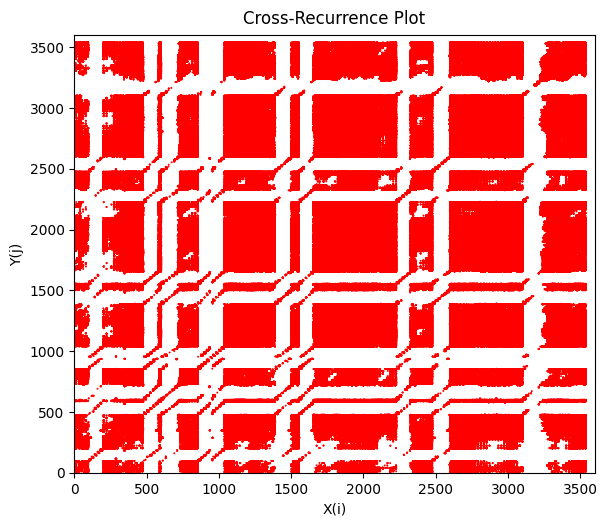

  ✅ RQA plot saved: rqa_blink_aperture_P414_H_w1800-5400.png
      %REC=26.87, %DET=93.68

Searching for example: mouth_aperture in condition M
  Found: P408 M window 2 (3600-7200)


KeyboardInterrupt: 

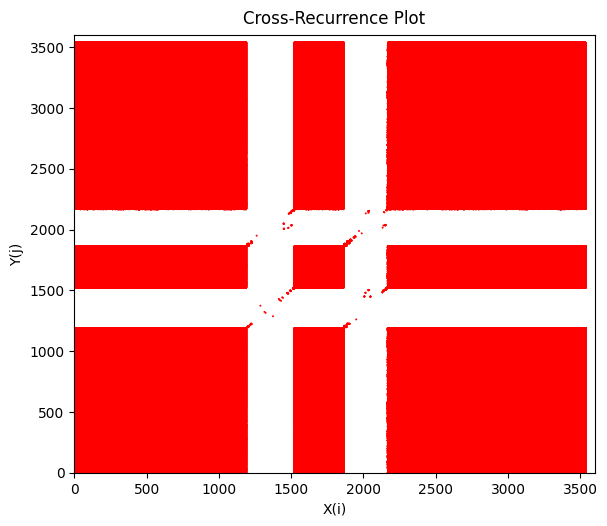

In [11]:
print("\n" + "="*70)
print("GENERATING EXAMPLE RECURRENCE PLOTS")
print("="*70)

examples_to_plot = [
    ("blink_aperture", "H"),
    ("mouth_aperture", "M"),
]

for column, condition in examples_to_plot:
    print(f"\nSearching for example: {column} in condition {condition}")
    res = find_interesting_window(df, column, metric="perc_recur", condition=condition)
    if res is None:
        print(f"  ⚠️  No data found")
        continue
    pid, cond, w_idx, w_start, w_end = res
    print(f"  Found: P{pid} {cond} window {w_idx} ({w_start}-{w_end})")
    generate_rqa_plot(cfg, pid, cond, column, w_start, w_end)


## CRQA Example

In [ ]:
print("\n" + "="*70)
print("GENERATING EXAMPLE CROSS-RECURRENCE PLOTS")
print("="*70)


crqa_mappings = {
    "original": {
        "crqa_head_pupil_x": ("center_face_x", "pupil_dx", "Head-Pupil X"),
        "crqa_head_pupil_y": ("center_face_y", "pupil_dy", "Head-Pupil Y"),
        "crqa_head_pupil_mag": ("center_face_magnitude", "pupil_metric", "Head-Pupil Mag"),
    },
    "procrustes_global": {
        "crqa_head_pupil_x": ("head_tx", "pupil_dx", "Head-Pupil X"),
        "crqa_head_pupil_y": ("head_ty", "pupil_dy", "Head-Pupil Y"),
        "crqa_head_pupil_mag": ("head_motion_mag", "pupil_metric", "Head-Pupil Mag"),
    }
}

if NORMALIZATION in crqa_mappings:
    for crqa_col, (head_col, pupil_col, label) in crqa_mappings[NORMALIZATION].items():
        if crqa_col not in df["column"].unique():
            continue
        print(f"\nSearching for example: {crqa_col}")
        res = find_interesting_window(df, crqa_col, metric="perc_recur", condition="H")
        if res is None:
            print(f"  ⚠️  No data found")
            continue
        pid, cond, w_idx, w_start, w_end = res
        print(f"  Found: P{pid} {cond} window {w_idx} ({w_start}-{w_end})")
        generate_crqa_plot(cfg, pid, cond, head_col, pupil_col, w_start, w_end, label)
